# Heatmap of Predictive Model Gene Signatures

This notebook identifies important genes from all predictive models (Naive Bayes, KNN, Logistic Regression, Random Forest) and creates a clustered heatmap with Assignment 1 group annotations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [7]:
# Load expression data - NOTE: CSV has samples as columns, genes as rows, NO gene name column
expression_data = pd.read_csv('expression_data.csv')

# Load group annotations first
groups = pd.read_csv('../data/processed/group_annotation.csv', index_col=0)

# Filter expression data to only include samples with group annotations
common_samples = expression_data.columns.intersection(groups.index)
expression_data = expression_data[common_samples]

gene_variances = expression_data.var(axis=1)
top_5000_genes = gene_variances.sort_values(ascending=False).head(5000).index
top_variable_expression = expression_data.loc[top_5000_genes].T

print(f"Total samples in expression data: {len(common_samples)}")
print(f"Expression data shape: {top_variable_expression.shape}")
print(f"Groups distribution:\n{groups.loc[common_samples, 'Group'].value_counts()}")

Total samples in expression data: 88
Expression data shape: (88, 5000)
Groups distribution:
Group
T0    44
T3    44
Name: count, dtype: int64


In [8]:
# Diagnostic: Find samples without matches
expression_samples = set(pd.read_csv('expression_data.csv').columns)
group_samples = set(pd.read_csv('../data/processed/group_annotation.csv', index_col=0).index)

print(f"Total samples in expression data: {len(expression_samples)}")
print(f"Total samples in group annotations: {len(group_samples)}")
print(f"Common samples: {len(expression_samples.intersection(group_samples))}")

# Samples in expression data but NOT in group annotations
missing_groups = expression_samples - group_samples
if missing_groups:
    print(f"\nSamples in expression data WITHOUT group annotations ({len(missing_groups)}):")
    for sample in sorted(missing_groups):
        print(f"  - {sample}")

# Samples in group annotations but NOT in expression data
missing_expression = group_samples - expression_samples
if missing_expression:
    print(f"\nSamples in group annotations WITHOUT expression data ({len(missing_expression)}):")
    for sample in sorted(missing_expression):
        print(f"  - {sample}")

Total samples in expression data: 88
Total samples in group annotations: 88
Common samples: 88


## Train/Test Split (30% test)

All models will use the same train/test split for consistency.

In [9]:
X = top_variable_expression
y = groups.loc[X.index, 'Group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training class distribution:\n{y_train.value_counts()}")
print(f"Test class distribution:\n{y_test.value_counts()}")

Training set: (61, 5000)
Test set: (27, 5000)
Training class distribution:
Group
T3    31
T0    30
Name: count, dtype: int64
Test class distribution:
Group
T0    14
T3    13
Name: count, dtype: int64


## 1. Logistic Regression - Extract Important Genes

In [10]:
# Train Logistic Regression with L1 penalty for feature selection
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(solver='liblinear', random_state=0, max_iter=1000))
])

param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']
}

grid_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
lr_accuracy = best_lr.score(X_test, y_test)

# Extract coefficients (feature importances)
lr_coefs = best_lr.named_steps['lr'].coef_[0]
lr_gene_importance = pd.DataFrame({
    'gene': X_train.columns,
    'coefficient': np.abs(lr_coefs)
}).sort_values('coefficient', ascending=False)

# Select top 100 genes by absolute coefficient
lr_top_genes = lr_gene_importance.head(100)['gene'].values

print(f"Logistic Regression Test Accuracy: {lr_accuracy:.4f}")
print(f"Best parameters: {grid_lr.best_params_}")
print(f"Number of genes selected: {len(lr_top_genes)}")
print(f"\nTop 10 genes by coefficient:")
print(lr_gene_importance.head(10))

Logistic Regression Test Accuracy: 1.0000
Best parameters: {'lr__C': 10, 'lr__penalty': 'l2'}
Number of genes selected: 100

Top 10 genes by coefficient:
       gene  coefficient
1904    104     0.049814
188    9256     0.048930
4053   7082     0.045897
3438   5710     0.045557
378    4848     0.045002
4023  16027     0.044211
1810  14399     0.043855
970   17182     0.043039
2864   2517     0.042662
1373  12585     0.042560


## 2. Random Forest - Extract Important Genes

In [11]:
# Train Random Forest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=0))
])

param_grid_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
rf_accuracy = best_rf.score(X_test, y_test)

# Extract feature importances
rf_importances = best_rf.named_steps['rf'].feature_importances_
rf_gene_importance = pd.DataFrame({
    'gene': X_train.columns,
    'importance': rf_importances
}).sort_values('importance', ascending=False)

# Select top 100 genes by importance
rf_top_genes = rf_gene_importance.head(100)['gene'].values

print(f"Random Forest Test Accuracy: {rf_accuracy:.4f}")
print(f"Best parameters: {grid_rf.best_params_}")
print(f"Number of genes selected: {len(rf_top_genes)}")
print(f"\nTop 10 genes by importance:")
print(rf_gene_importance.head(10))

Random Forest Test Accuracy: 1.0000
Best parameters: {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Number of genes selected: 100

Top 10 genes by importance:
       gene  importance
963   19103    0.014661
3259    980    0.011847
783   14920    0.011548
3053   2131    0.009298
625   15749    0.007906
2153   2098    0.007783
913   17035    0.007507
4453  12677    0.007394
1695   6074    0.007315
1026  13960    0.007133


## 3. Naive Bayes - Extract Important Genes

For Naive Bayes, we'll use the variance ratio between classes as a proxy for importance.

In [12]:
# Train Naive Bayes
nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

param_grid_nb = {
    'nb__var_smoothing': np.logspace(-10, -8, 10)
}

grid_nb = GridSearchCV(nb_pipeline, param_grid_nb, cv=5, scoring='accuracy', n_jobs=-1)
grid_nb.fit(X_train, y_train)

best_nb = grid_nb.best_estimator_
nb_accuracy = best_nb.score(X_test, y_test)

# For Naive Bayes, calculate class-specific means and variances
# Use standardized data
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Calculate mean difference between classes as importance measure
mean_T0 = X_train_scaled[y_train == 'T0'].mean()
mean_T3 = X_train_scaled[y_train == 'T3'].mean()
nb_gene_importance = pd.DataFrame({
    'gene': X_train.columns,
    'mean_diff': np.abs(mean_T0 - mean_T3)
}).sort_values('mean_diff', ascending=False)

# Select top 100 genes by mean difference
nb_top_genes = nb_gene_importance.head(100)['gene'].values

print(f"Naive Bayes Test Accuracy: {nb_accuracy:.4f}")
print(f"Best parameters: {grid_nb.best_params_}")
print(f"Number of genes selected: {len(nb_top_genes)}")
print(f"\nTop 10 genes by mean difference:")
print(nb_gene_importance.head(10))

Naive Bayes Test Accuracy: 0.8889
Best parameters: {'nb__var_smoothing': np.float64(1e-10)}
Number of genes selected: 100

Top 10 genes by mean difference:
        gene  mean_diff
7022    7022   1.447765
17182  17182   1.370708
4107    4107   1.339088
13539  13539   1.263711
10543  10543   1.253602
2246    2246   1.250822
6074    6074   1.250203
4718    4718   1.246280
17035  17035   1.225484
13198  13198   1.219838


## 4. KNN - Extract Important Genes

For KNN, we'll use correlation with class labels as importance measure.

In [13]:
# Train KNN
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': range(1, 21, 2)
}

grid_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_
knn_accuracy = best_knn.score(X_test, y_test)

# For KNN, calculate point-biserial correlation with binary class labels
y_train_binary = (y_train == 'T3').astype(int)
knn_gene_importance = pd.DataFrame({
    'gene': X_train.columns,
    'correlation': [np.abs(np.corrcoef(X_train[col], y_train_binary)[0, 1]) 
                   for col in X_train.columns]
}).sort_values('correlation', ascending=False)

# Select top 100 genes by correlation
knn_top_genes = knn_gene_importance.head(100)['gene'].values

print(f"KNN Test Accuracy: {knn_accuracy:.4f}")
print(f"Best parameters: {grid_knn.best_params_}")
print(f"Number of genes selected: {len(knn_top_genes)}")
print(f"\nTop 10 genes by correlation:")
print(knn_gene_importance.head(10))

KNN Test Accuracy: 0.9259
Best parameters: {'knn__n_neighbors': 1}
Number of genes selected: 100

Top 10 genes by correlation:
       gene  correlation
520    7022     0.723785
970   17182     0.685262
769    4107     0.669454
649   13539     0.631770
631   10543     0.626717
263    2246     0.625327
1695   6074     0.625017
972    4718     0.623056
913   17035     0.612660
1339  13198     0.609837


## Combine Gene Signatures from All Models

In [14]:
# Create union of all gene signatures
all_signature_genes = np.unique(np.concatenate([
    lr_top_genes,
    rf_top_genes,
    nb_top_genes,
    knn_top_genes
]))

print(f"\nGene Signature Summary:")
print(f"="*50)
print(f"Logistic Regression: {len(lr_top_genes)} genes")
print(f"Random Forest: {len(rf_top_genes)} genes")
print(f"Naive Bayes: {len(nb_top_genes)} genes")
print(f"KNN: {len(knn_top_genes)} genes")
print(f"\nUnion of all signatures: {len(all_signature_genes)} unique genes")

# Count how many models selected each gene
gene_counts = {}
for gene in all_signature_genes:
    count = sum([
        gene in lr_top_genes,
        gene in rf_top_genes,
        gene in nb_top_genes,
        gene in knn_top_genes
    ])
    gene_counts[gene] = count

gene_count_df = pd.DataFrame([
    {'gene': gene, 'num_models': count} 
    for gene, count in gene_counts.items()
]).sort_values('num_models', ascending=False)

print(f"\nGenes selected by multiple models:")
print(gene_count_df['num_models'].value_counts().sort_index(ascending=False))
print(f"\nTop genes selected by all 4 models:")
print(gene_count_df[gene_count_df['num_models'] == 4].head(10))


Gene Signature Summary:
Logistic Regression: 100 genes
Random Forest: 100 genes
Naive Bayes: 100 genes
KNN: 100 genes

Union of all signatures: 225 unique genes

Genes selected by multiple models:
num_models
4     19
3     33
2     52
1    121
Name: count, dtype: int64

Top genes selected by all 4 models:
      gene  num_models
89    6074           4
62    4504           4
40    3152           4
86    5710           4
176  13764           4
177  13960           4
47    3606           4
28    2131           4
27    2098           4
146  10543           4


## Create Clustered Heatmap with Group Annotations

In [15]:
# Extract expression data for signature genes
heatmap_data = expression_data.loc[all_signature_genes].T

# Align with group annotations
heatmap_data = heatmap_data.loc[groups.index]
group_labels = groups.loc[heatmap_data.index, 'Group']

# Create color mapping for groups
group_colors = {'T0': '#3498db', 'T3': '#e74c3c'}  # Blue for T0, Red for T3
row_colors = group_labels.map(group_colors)

print(f"\nHeatmap data shape: {heatmap_data.shape}")
print(f"Samples: {heatmap_data.shape[0]}, Genes: {heatmap_data.shape[1]}")


Heatmap data shape: (88, 225)
Samples: 88, Genes: 225



Heatmap saved to: ../results/figures/predictive_models_heatmap.png


<Figure size 2000x1200 with 0 Axes>

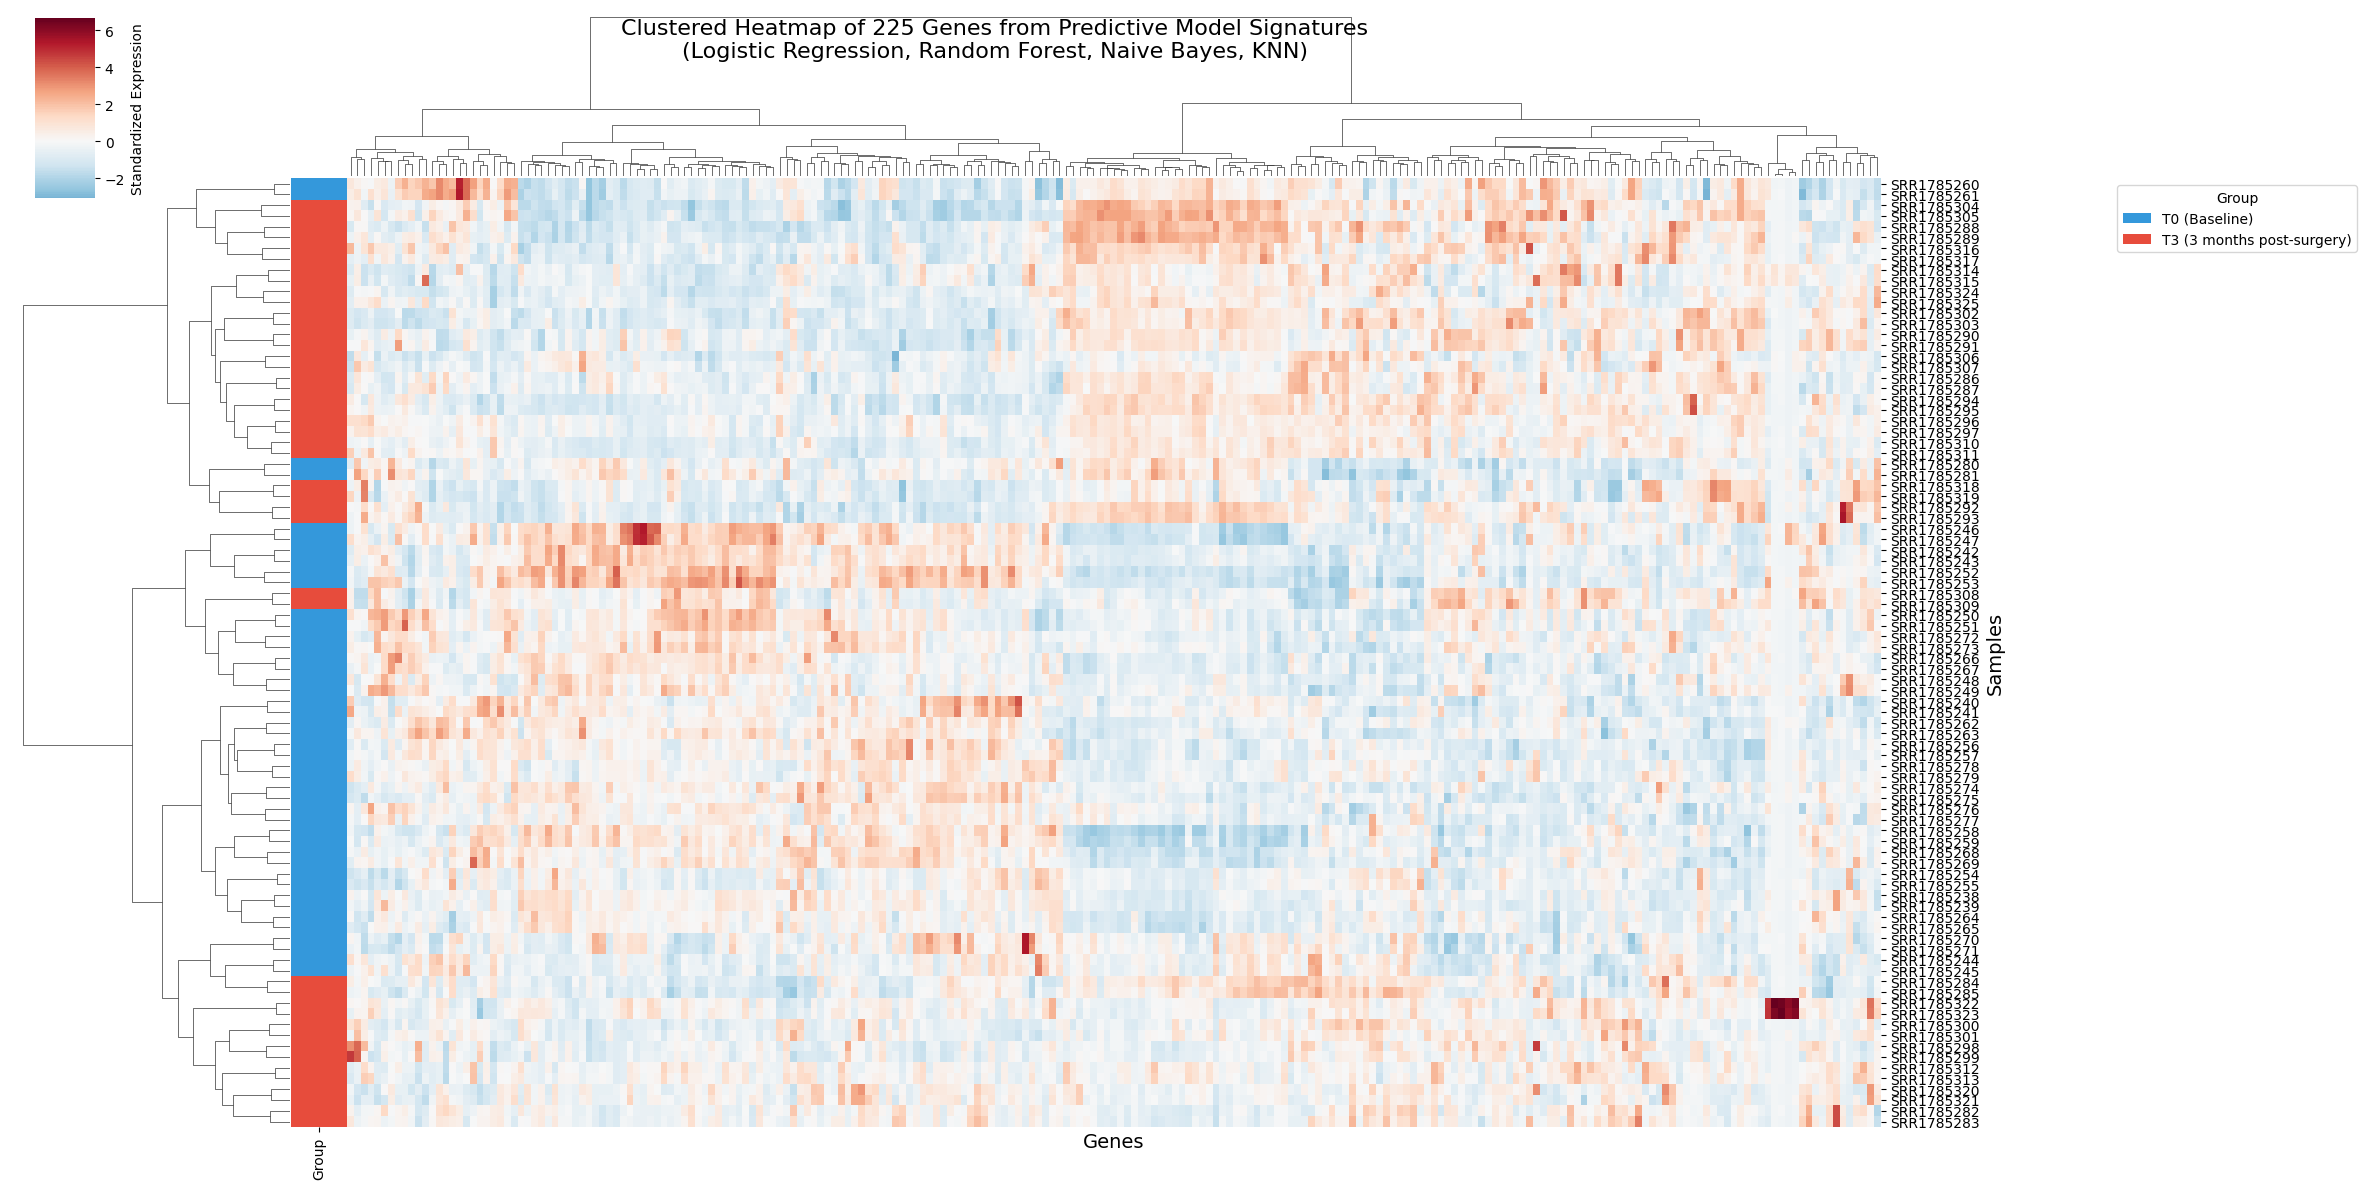

In [16]:
# Create clustered heatmap using seaborn clustermap
plt.figure(figsize=(20, 12))

# Standardize data for better visualization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
heatmap_data_scaled = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

# Create clustermap with dendrograms
g = sns.clustermap(
    heatmap_data_scaled,
    cmap='RdBu_r',
    center=0,
    row_colors=row_colors,
    figsize=(20, 12),
    cbar_pos=(0.02, 0.83, 0.03, 0.15),
    dendrogram_ratio=0.15,
    linewidths=0,
    xticklabels=False,  # Too many genes to show labels
    yticklabels=True,
    cbar_kws={'label': 'Standardized Expression'},
    method='ward',
    metric='euclidean'
)

# Add title
g.fig.suptitle(
    f'Clustered Heatmap of {len(all_signature_genes)} Genes from Predictive Model Signatures\n'
    f'(Logistic Regression, Random Forest, Naive Bayes, KNN)',
    fontsize=16,
    y=0.98
)

# Add axis labels
g.ax_heatmap.set_xlabel('Genes', fontsize=14)
g.ax_heatmap.set_ylabel('Samples', fontsize=14)

# Create custom legend for group colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=group_colors['T0'], label='T0 (Baseline)'),
    Patch(facecolor=group_colors['T3'], label='T3 (3 months post-surgery)')
]
g.ax_heatmap.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.15, 1),
    title='Group',
    frameon=True
)

plt.savefig('../results/figures/predictive_models_heatmap.png', dpi=300, bbox_inches='tight')
print("\nHeatmap saved to: ../results/figures/predictive_models_heatmap.png")
plt.show()

## Focused Heatmap: 19 Genes Selected by All 4 Models

In [ ]:
# Extract genes selected by all 4 models
consensus_genes = gene_count_df[gene_count_df['num_models'] == 4]['gene'].values

print(f"Consensus genes (selected by all 4 models): {len(consensus_genes)}")
print(f"Gene IDs: {consensus_genes}")

# Extract expression data for consensus genes
heatmap_data_consensus = expression_data.loc[consensus_genes].T

# Align with group annotations
heatmap_data_consensus = heatmap_data_consensus.loc[groups.index]
group_labels_consensus = groups.loc[heatmap_data_consensus.index, 'Group']

# Create color mapping for groups
row_colors_consensus = group_labels_consensus.map(group_colors)

# Standardize data for better visualization
scaler_consensus = StandardScaler()
heatmap_data_consensus_scaled = pd.DataFrame(
    scaler_consensus.fit_transform(heatmap_data_consensus),
    index=heatmap_data_consensus.index,
    columns=heatmap_data_consensus.columns
)

# Create clustermap with dendrograms
g_consensus = sns.clustermap(
    heatmap_data_consensus_scaled,
    cmap='RdBu_r',
    center=0,
    row_colors=row_colors_consensus,
    figsize=(12, 12),
    cbar_pos=(0.02, 0.83, 0.03, 0.15),
    dendrogram_ratio=0.15,
    linewidths=0.5,
    xticklabels=True,  # Show gene labels since there are only 19
    yticklabels=True,
    cbar_kws={'label': 'Standardized Expression'},
    method='ward',
    metric='euclidean'
)

# Rotate x-axis labels for readability
plt.setp(g_consensus.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=9)

# Add title
g_consensus.fig.suptitle(
    f'Clustered Heatmap of {len(consensus_genes)} Consensus Genes\n'
    f'(Selected by All 4 Models: Logistic Regression, Random Forest, Naive Bayes, KNN)',
    fontsize=14,
    y=0.98
)

# Add axis labels
g_consensus.ax_heatmap.set_xlabel('Genes', fontsize=12)
g_consensus.ax_heatmap.set_ylabel('Samples', fontsize=12)

# Create custom legend for group colors
legend_elements_consensus = [
    Patch(facecolor=group_colors['T0'], label='T0 (Baseline)'),
    Patch(facecolor=group_colors['T3'], label='T3 (3 months post-surgery)')
]
g_consensus.ax_heatmap.legend(
    handles=legend_elements_consensus,
    loc='upper left',
    bbox_to_anchor=(1.2, 1),
    title='Group',
    frameon=True
)

plt.savefig('../results/figures/consensus_genes_heatmap.png', dpi=300, bbox_inches='tight')
print("\nConsensus genes heatmap saved to: ../results/figures/consensus_genes_heatmap.png")
plt.show()

## Summary Statistics

In [17]:
# Create summary table
summary_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Naive Bayes', 'KNN'],
    'Test Accuracy': [lr_accuracy, rf_accuracy, nb_accuracy, knn_accuracy],
    'Genes Selected': [len(lr_top_genes), len(rf_top_genes), len(nb_top_genes), len(knn_top_genes)],
    'Best Params': [
        str(grid_lr.best_params_),
        str(grid_rf.best_params_),
        str(grid_nb.best_params_),
        str(grid_knn.best_params_)
    ]
})

print("\n" + "="*80)
print("PREDICTIVE MODEL SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("\n" + "="*80)
print(f"Total unique genes in combined signature: {len(all_signature_genes)}")
print("="*80)

# Save gene signatures
gene_count_df.to_csv('../results/predictive_model_gene_signatures.csv', index=False)
print("\nGene signatures saved to: ../results/predictive_model_gene_signatures.csv")


PREDICTIVE MODEL SUMMARY
              Model  Test Accuracy  Genes Selected                                                                  Best Params
Logistic Regression       1.000000             100                                           {'lr__C': 10, 'lr__penalty': 'l2'}
      Random Forest       1.000000             100 {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
        Naive Bayes       0.888889             100                                     {'nb__var_smoothing': np.float64(1e-10)}
                KNN       0.925926             100                                                      {'knn__n_neighbors': 1}

Total unique genes in combined signature: 225

Gene signatures saved to: ../results/predictive_model_gene_signatures.csv
